In [80]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as mtri

matplotlib.rcParams['figure.dpi'] = 250
# plt.style.use('seaborn-v0_8-notebook')
plt.style.use('seaborn-v0_8-paper')

In [48]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
with open('ee_cache.json', 'r') as f:
    data = json.load(f)

In [34]:
ee_final_positions = [data[i][0] for i in range(len(data))]
ee_final_positions = np.array(ee_final_positions)
x, y, z = ee_final_positions[:,0], ee_final_positions[:,1], ee_final_positions[:,2]
assert len(x) == len(y)
assert len(y) == len(z)

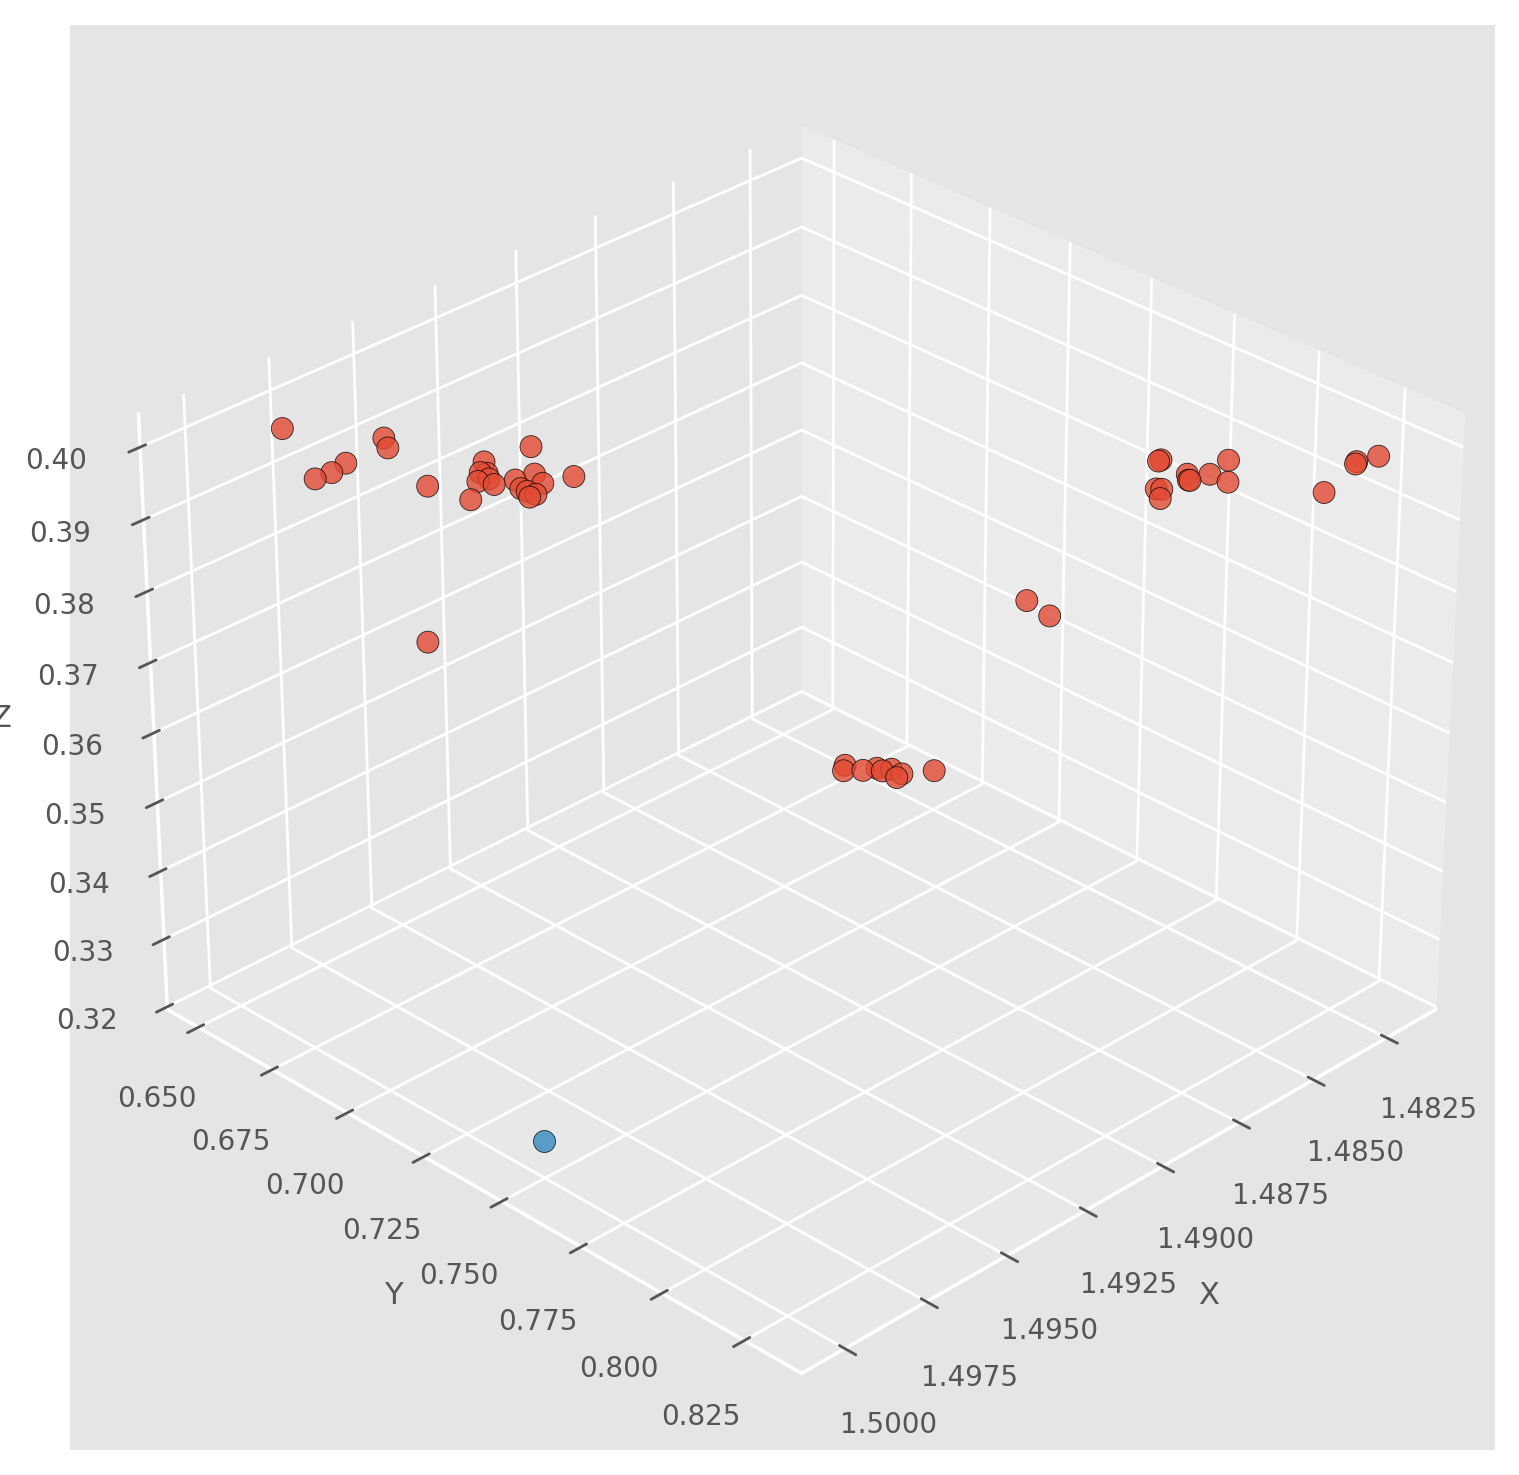

<Figure size 1600x1100 with 0 Axes>

In [81]:
#Scatter Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=40, edgecolor='k', alpha=0.8, antialiased=True)
ax.scatter(1.5, 0.75, 0.325, s = 40, edgecolor='k', alpha=0.8, antialiased=True)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()

In [96]:
#Deviations along x, y and z:
x_dev = np.array([1.5 - i for i in ee_final_positions[:,0]])
y_dev = np.array([0.75 - i for i in ee_final_positions[:,1]])
z_dev = np.array([0.325 - i for i in ee_final_positions[:,2]])

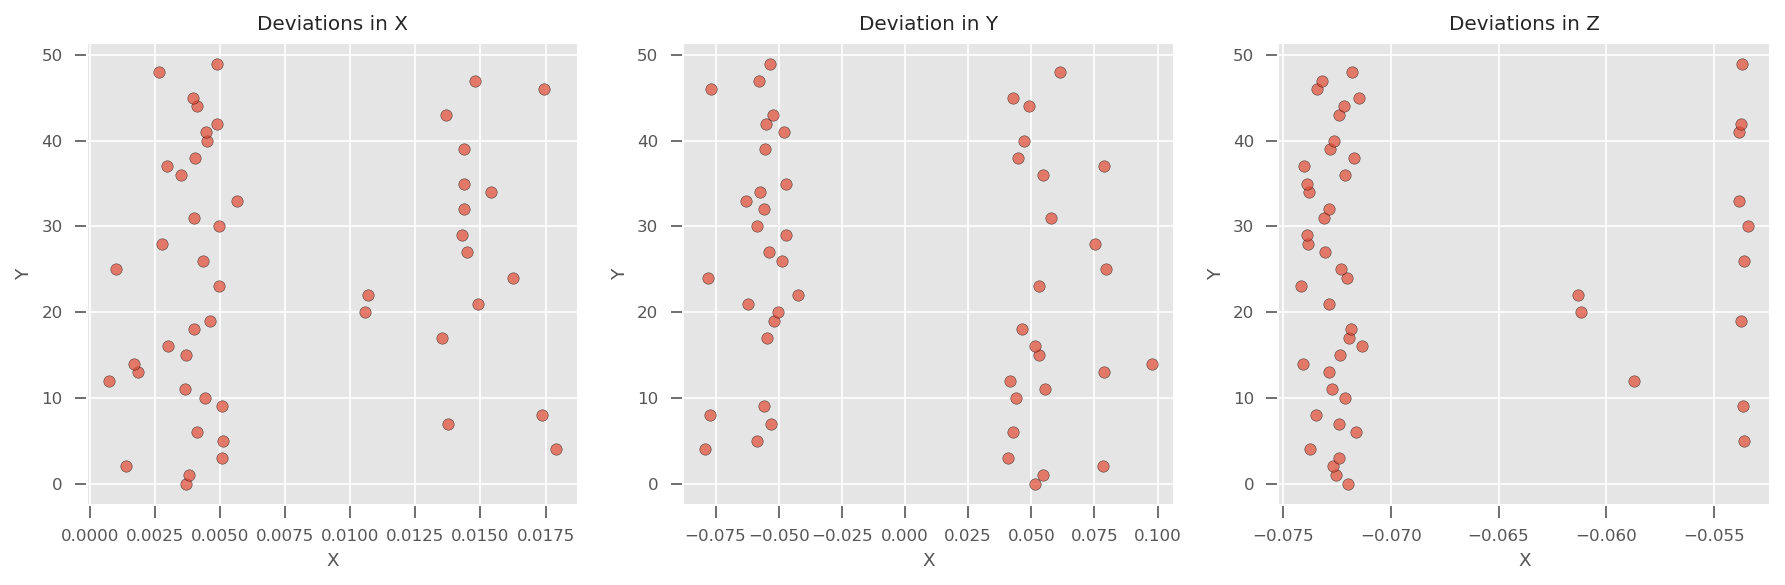

In [106]:
# Create scatterplots with 1 row, 3 columns
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), dpi=150)

# Plot into each axis
for ax, data, title in zip(axes,
                           [x_dev, y_dev, z_dev],
                           ['Deviations in X', 'Deviation in Y', 'Deviations in Z']):
    x = data
    y = [range(0,50)]
    ax.scatter(x, y, s=30, alpha=0.7, edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

In [107]:
#Eucledian distance between the points:
eucledian_dist = [np.linalg.norm(np.array([1.5, 0.75, 0.325]) - i) for i in ee_final_positions]

In [115]:
print(f"\nMaximum distance from EE position: {max(eucledian_dist)}")
print(f"\nMinimumdistance from EE position: {min(eucledian_dist)}")


Maximum distance from EE position: 0.12262286372463536

Minimumdistance from EE position: 0.07202378167786089


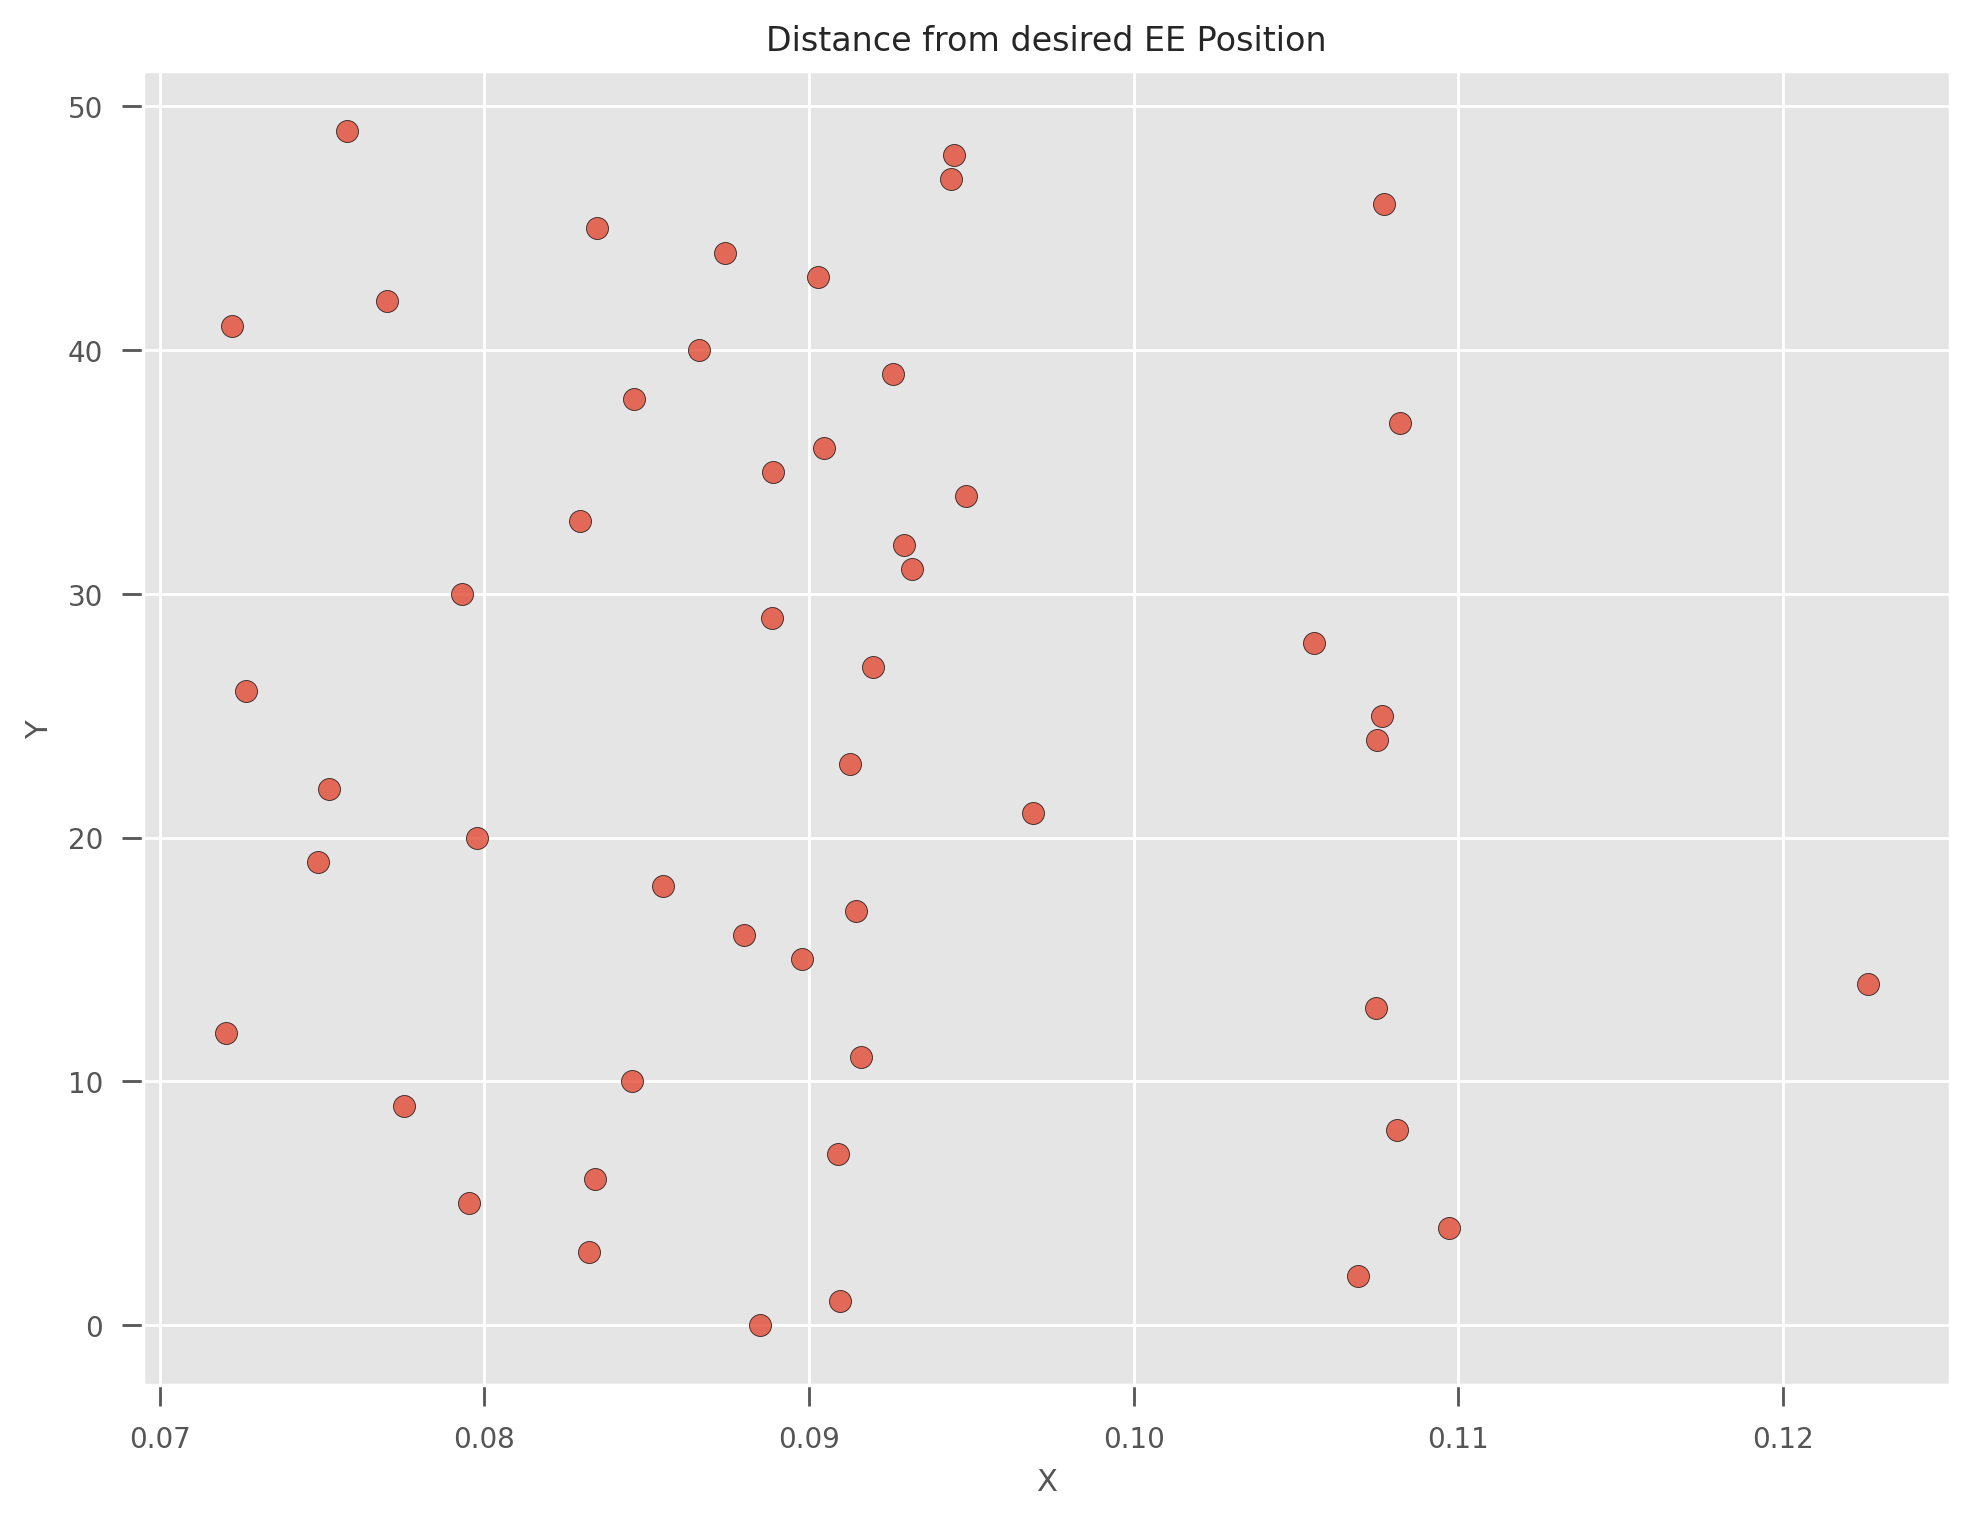

<Figure size 1600x1100 with 0 Axes>

In [112]:
#Scatter Plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
ax.scatter(eucledian_dist, [range(0,50)], s=40, edgecolor='k', alpha=0.8, antialiased=True)

ax.set_xlabel('X')
ax.set_ylabel('Y')
#ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.title("Distance from desired EE Position")
plt.show()

ax.set_xlabel('X')
ax.set_ylabel('Y')
#ax.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()